# Exercise 3
We copy the notebook from [LV_pz.ipynb](https://github.com/mvichi/HonsUCT_IntroOceMod/blob/master/notebooks/LV_pz.ipynb) to use a s a template for the exercise.

## The Lotka-Volterra model
This model is a python translation of the LV_pz model proposed in Glover et al. (2011), Sec. 9.3

You will need to make sure the required modules below are installed in your python environment

In [26]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

This is the function containing the right hand side of the ODE system

In [27]:
def LV_pz(x,t,p):
    X1,X2 = x
    p1,p2,p3,p4 = p
    dX1dt = X1 * (p1 - p2*X2)
    dX2dt = X2 * (p3*p2*X1 - p4)
    return np.array([dX1dt,dX2dt])

### Parameters and initial conditions

In [28]:
# The parameters
p = np.array([0.1,0.4,0.2,0.05])
X1_0 = 0.8
X2_0 = 0.171
x0 = np.array([X1_0,X2_0])

### Time axis

In [29]:
# time units are days
Tstart = 0.
Tend = 400.
step = 0.1
t = np.arange(Tstart,Tend,step)

### Integration using the scipy ODE solver

In [30]:
# note that the extra argument containing the parameter "args" must be a tuple
y = odeint(LV_pz, x0, t, args=(p,))

### Plot Fig. 9.3a

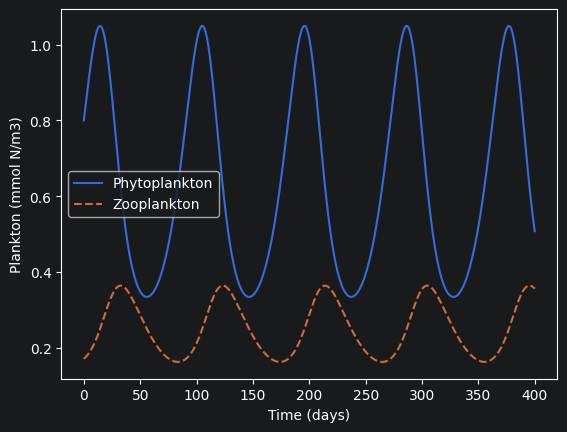

In [31]:
plt.plot(t,y[:,0],'-',label='Phytoplankton')
plt.plot(t,y[:,1],'--',label='Zooplankton')
plt.xlabel('Time (days)')
plt.ylabel('Plankton (mmol N/m3)')
plt.legend()
plt.show()

# Exercise 3
1. Write the code to plot Fig. 9.3b, the trajectory in the phase space

Text(0.5, 1.0, 'Phase space of Zooplankton and Phytoplankton')

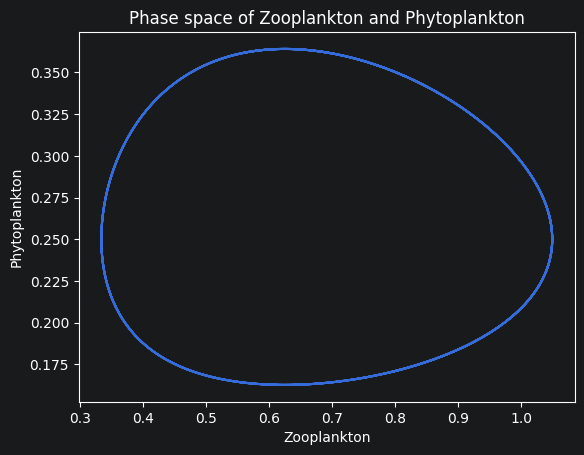

In [32]:
plt.figure()
zoop = y[:,0]
phyt = y[:,1]
plt.plot(zoop, phyt)
plt.xlabel('Zooplankton')
plt.ylabel('Phytoplankton')
plt.title("Phase space of Zooplankton and Phytoplankton")

2. Set the parameter p3=1 and compare how different the trajectory is in the phase space

Text(0.5, 1.0, 'Phase space of Zooplankton and Phytoplankton with p_3 = 1')

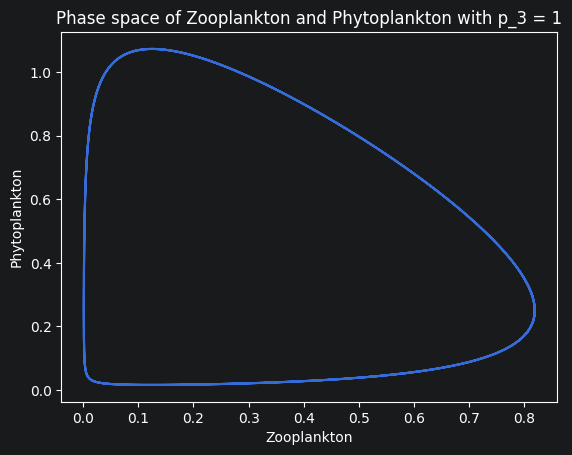

In [33]:
# The parameters
p[2] = 1
y = odeint(LV_pz, x0, t, args=(p,))

plt.figure()
zoop = y[:,0]
phyt = y[:,1]
plt.plot(zoop, phyt)
plt.xlabel('Zooplankton')
plt.ylabel('Phytoplankton')
plt.title("Phase space of Zooplankton and Phytoplankton with p_3 = 1")

We see a more pronounced variation in the phytoplankton concentration, with a much sharper change in both near the origin.

3. Write the code to compute the solution of the L-V model using the initial conditions given in the caption of Fig. 9.4

Text(0.5, 1.0, 'Phase space of Zooplankton and Phytoplankton with the initial conditions from Glover et Al')

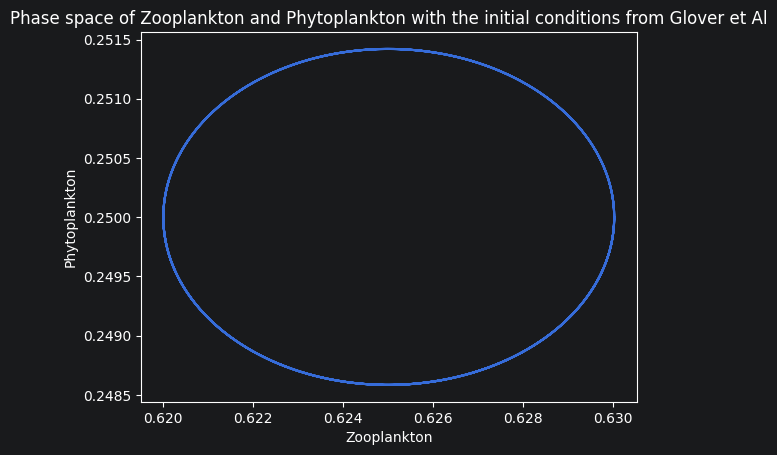

In [34]:
p = np.array([0.1,0.4,0.2,0.05])
X1_0 = 0.62
X2_0 = 0.25
x0 = np.array([X1_0,X2_0])
y = odeint(LV_pz, x0, t, args=(p,))

plt.figure()
zoop = y[:,0]
phyt = y[:,1]
plt.plot(zoop, phyt)
plt.xlabel('Zooplankton')
plt.ylabel('Phytoplankton')
plt.title("Phase space of Zooplankton and Phytoplankton with the initial conditions from Glover et Al")

4. Do you get the same results? Why not? See the errata in the document Glover_etal_2011_ERRATA.pdf to understand more {no need to fully understand the stability analysis ;)}

We get a periodic solution (as seen by the phase space being a closed curve) unlike the one in Glover, which is spirals outward. This is because their solution is using an unstable (and incorrect) numerical scheme.